In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn import tree
from IPython.display import SVG
from graphviz import Source
from IPython.display import display

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Copy of daily_weather (1).csv')

In [4]:
df.head()

,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,high_humidity_3pm
0,918.060000,74.822000,271.100000,2.080354,295.400000,2.863283,0.0,0.0,42.420000,1
1,917.347688,71.403843,101.935179,2.443009,140.471549,3.533324,0.0,0.0,24.328697,0
2,923.040000,60.638000,51.000000,17.067852,63.700000,22.100967,0.0,20.0,8.900000,0
3,920.502751,70.138895,198.832133,4.337363,211.203341,5.190045,0.0,0.0,12.189102,0
4,921.160000,44.294000,277.800000,1.856660,136.500000,2.863283,8.9,14730.0,92.410000,1


In [5]:
df.describe()

,air_pressure_9am,air_temp_9am,avg_wind_direction_9am,avg_wind_speed_9am,max_wind_direction_9am,max_wind_speed_9am,rain_accumulation_9am,rain_duration_9am,relative_humidity_9am,high_humidity_3pm
count,1092.000000,1090.000000,1091.000000,1092.000000,1092.000000,1091.000000,1089.000000,1092.000000,1095.000000,1095.000000
mean,918.882551,64.933001,142.235511,5.508284,148.953518,7.019514,0.203079,294.108052,34.241402,0.499543
std,3.184161,11.175514,69.137859,4.552813,67.238013,5.598209,1.593952,1598.078779,25.472067,0.500228
min,907.990000,36.752000,15.500000,0.693451,28.900000,1.185578,0.000000,0.000000,6.090000,0.000000
25%,916.550000,57.281000,65.972506,2.248768,76.553003,3.067477,0.000000,0.000000,15.092243,0.000000
50%,918.921045,65.715479,166.000000,3.871333,177.300000,4.943637,0.000000,0.000000,23.179259,0.000000
75%,921.160073,73.450974,191.000000,7.337163,201.233153,8.947760,0.000000,0.000000,45.400000,1.000000
max,929.320000,98.906000,343.400000,23.554978,312.200000,29.840780,24.020000,17704.000000,92.620000,1.000000


array([[<Axes: title={'center': 'air_pressure_9am'}>,
        <Axes: title={'center': 'air_temp_9am'}>,
        <Axes: title={'center': 'avg_wind_direction_9am'}>],
       [<Axes: title={'center': 'avg_wind_speed_9am'}>,
        <Axes: title={'center': 'max_wind_direction_9am'}>,
        <Axes: title={'center': 'max_wind_speed_9am'}>],
       [<Axes: title={'center': 'rain_accumulation_9am'}>,
        <Axes: title={'center': 'rain_duration_9am'}>,
        <Axes: title={'center': 'relative_humidity_9am'}>],
       [<Axes: title={'center': 'high_humidity_3pm'}>, <Axes: >,
        <Axes: >]], dtype=object)

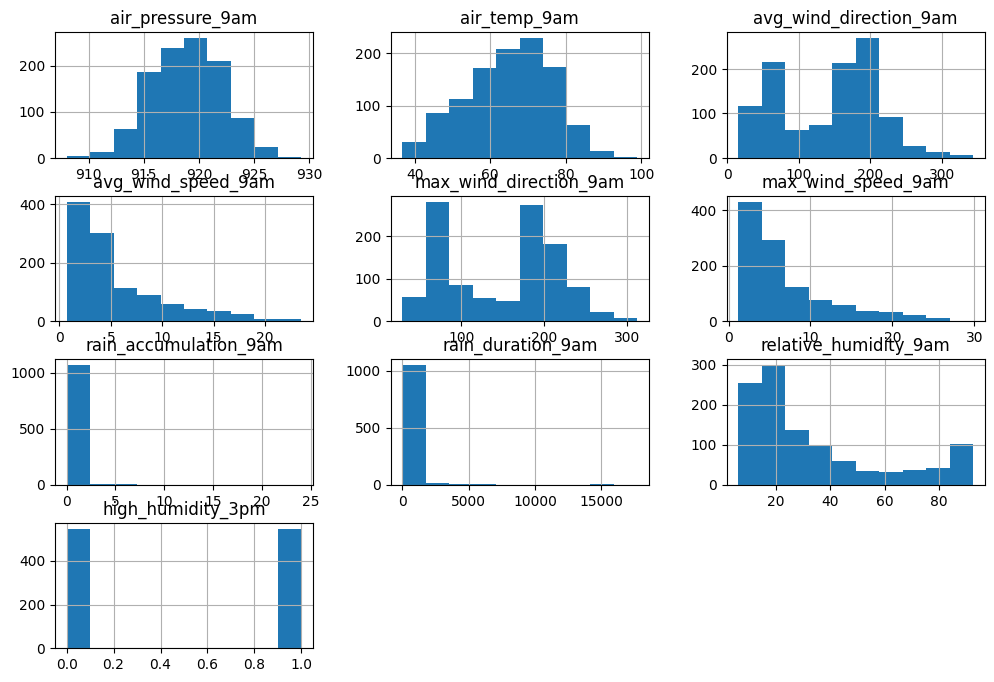

In [6]:
df.hist(figsize=(12,8))

<Axes: >

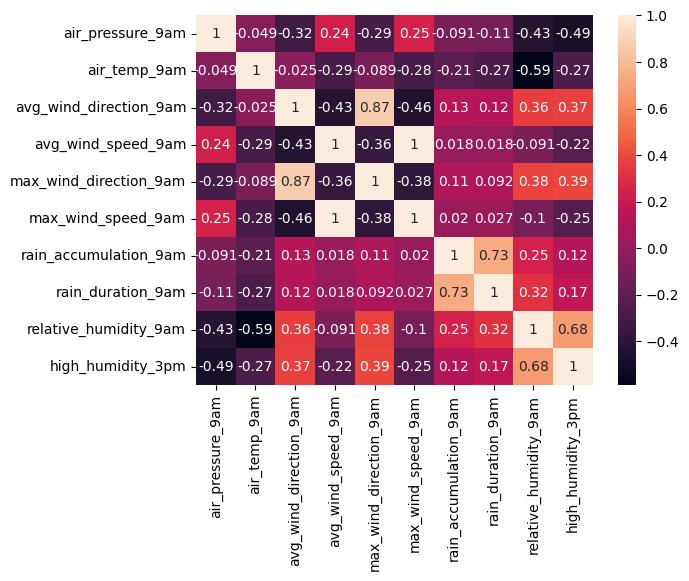

In [7]:
sns.heatmap(df.corr(), annot=True)

In [8]:
df['high_humidity_3pm'].value_counts()

,count
high_humidity_3pm,
0,548
1,547


In [9]:
df.isnull().sum()

,0
air_pressure_9am,3
air_temp_9am,5
avg_wind_direction_9am,4
avg_wind_speed_9am,3
max_wind_direction_9am,3
max_wind_speed_9am,4
rain_accumulation_9am,6
rain_duration_9am,3
relative_humidity_9am,0
high_humidity_3pm,0


In [10]:
df.dropna(inplace=True)

In [11]:
df.shape

(1064, 10)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1064 entries, 0 to 1094
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   air_pressure_9am        1064 non-null   float64
 1   air_temp_9am            1064 non-null   float64
 2   avg_wind_direction_9am  1064 non-null   float64
 3   avg_wind_speed_9am      1064 non-null   float64
 4   max_wind_direction_9am  1064 non-null   float64
 5   max_wind_speed_9am      1064 non-null   float64
 6   rain_accumulation_9am   1064 non-null   float64
 7   rain_duration_9am       1064 non-null   float64
 8   relative_humidity_9am   1064 non-null   float64
 9   high_humidity_3pm       1064 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 91.4 KB


In [14]:
x = df.drop('high_humidity_3pm', axis=1)
y = df['high_humidity_3pm']

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [28]:
from sklearn.preprocessing import StandardScaler

In [17]:
#scaler = StandardScaler()
#x_train = scaler.fit_transform(x_train)
#x_test = scaler.transform(x_test)

In [38]:
#model = DecisionTreeClassifier()
#model.fit(x_train, y_train)

In [48]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [49]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

In [50]:
train_pred[:5]

array([1, 1, 1, 0, 0])

In [51]:
y_train.values[:5]

array([1, 0, 1, 0, 0])

In [52]:
print('Train Accuracy Score :-',accuracy_score(y_train, train_pred))
print('Train confusion_matrix Score :-\n',confusion_matrix(y_train, train_pred))

Train Accuracy Score :- 0.8965922444183314
Train confusion_matrix Score :-
 [[388  45]
 [ 43 375]]


In [53]:
print('Test Accuracy Score:-',accuracy_score(y_test, test_pred))
print('Test confusion_matrix Score :-\n',confusion_matrix(y_test, test_pred))


Test Accuracy Score:- 0.8826291079812206
Test confusion_matrix Score :-
 [[91 11]
 [14 97]]


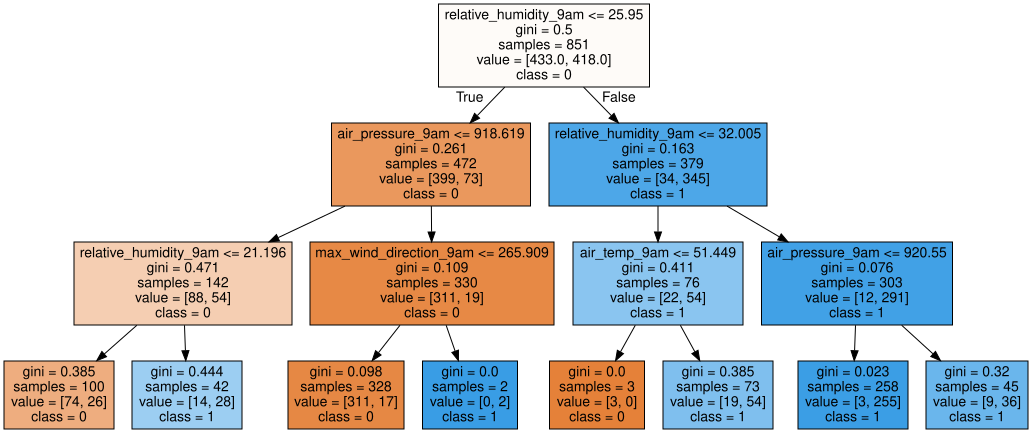

In [54]:
graph = Source(tree.export_graphviz(model, out_file=None
   , feature_names=x.columns, class_names=['0', '1']
   , filled = True))
display(SVG(graph.pipe(format='svg')))